# Implementing the Backpropagation Algorithm

A Multilayer Perceptron Neural Network is trained using the Backpropagation Algorithm on a custom dataset.

## Initializing the Libraries

In [148]:
!pip install numpy matplotlib 
!pip install imblearn imbalanced-learn

#imbalanced learn (dependent on scipy) is neaded for SMOTE.

In [149]:
!python --version
!pip list | grep -E "imblearn"

Python 3.12.2
imblearn                          0.0


# The Dataset

## Loading the Dataset

In [150]:
import numpy as np
import os, csv

# loading the data
DATASET     = np.loadtxt(os.path.join("dataset", "data.csv"), delimiter=",")
DATALABELS  = np.loadtxt(os.path.join("dataset", "data_labels.csv"), delimiter=",", dtype=int)
TESTSET     = np.loadtxt(os.path.join("dataset", "test_set.csv"), delimiter=",")

print(f"DATASET : {DATASET.shape}")
print(f"DATALABELS : {DATALABELS.shape}  classes: {np.unique(DATALABELS)}")
print(f"TESTSET : {TESTSET.shape}")

CLASSES = int(np.max(DATALABELS)) #1,2,3,4,5,6,7,8
LABELS = np.zeros((len(DATALABELS), CLASSES), dtype=float) #what class is the data
for _i, label in enumerate(DATALABELS):
    LABELS[_i, int(label) - 1] = 1.0

print(f"LABELS   : {LABELS.shape}")
print(f"Sample   : label {DATALABELS[0]} → {LABELS[0]}")


DATASET : (3486, 354)
DATALABELS : (3486,)  classes: [1 2 3 4 5 6 7 8]
TESTSET : (701, 354)
LABELS   : (3486, 8)
Sample   : label 8 → [0. 0. 0. 0. 0. 0. 0. 1.]


## Dataset Distribution

To observe how balanced or unbalanced the dataset is...

In [151]:
def piechart(datalabels, title='Class Distribution'): #use trainingset labels
    classcounts = np.bincount(datalabels, minlength=9)[1:]
    labels = [f"Class {i}" for i in range(1, len(classcounts) + 1)]

    plt.figure(figsize=(10, 8))
    plt.pie(classcounts, autopct=lambda pct: f'{int(pct/100.*sum(classcounts))}\n({pct:.1f}%)', startangle=90)
    plt.legend(labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title(title)
    plt.axis('equal')
    plt.show()

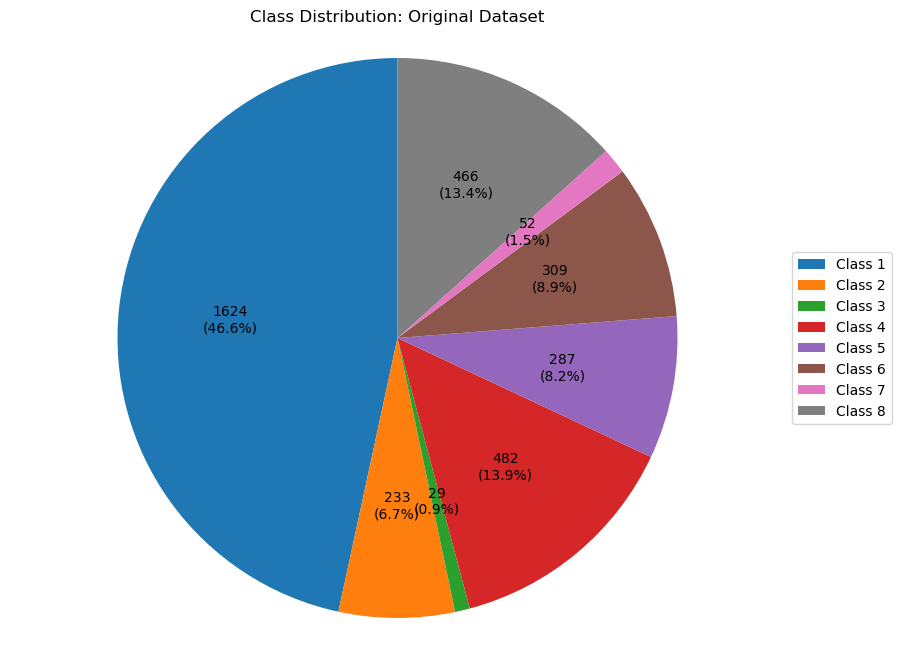

In [152]:
piechart(DATALABELS, "Class Distribution: Original Dataset") #the original

As you can see, the distribution of Network A heavily favors Class 1 with 46.6% of the dataset, with Class 3 having the lowest distribution of only 0.9%. 

Training the model like so be unbalanced, and therefore balancing methods will be considered when pre-processing the data.

## SMOTE (Synthetic Minority Over-sampling Technique)

A common pre-processing technique is by using **Synthetic Minority Over-sampling Techinque** as highlighted in this article: https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/

Initializing the `applysmote()` function:

In [153]:
X = DATASET
y = DATALABELS

from imblearn.over_sampling import SMOTE

X_balanced, y_balanced = SMOTE(random_state=50).fit_resample(X, y)

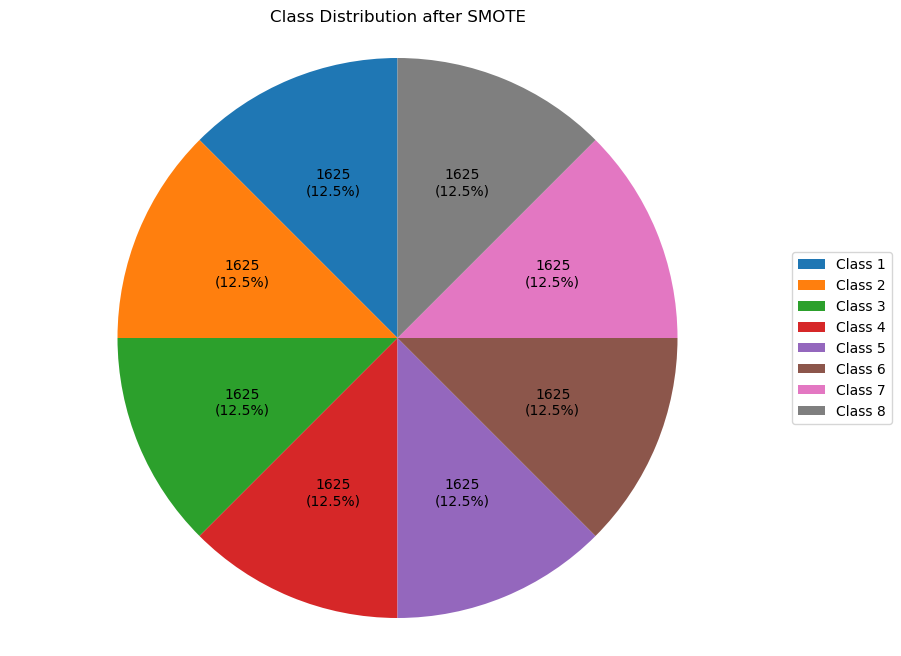

In [154]:
piechart(y_balanced, "Class Distribution after SMOTE")

The dataset is now balanced and ready for training. It was noted that "data leakage" could occur since splitting will be done AFTER the balancing.

## Partitioning the dataset

Now that we have a BALANCED (randomized) dataset, 

In [155]:
valsize = 800 # fixed validation set size

class Partition: #X is the dataset, y is the datalabels
    def __init__(self, X, y, valsize=800, outputdir="export", randomstate=50):
        os.makedirs(outputdir, exist_ok=True)
        rng = np.random.default_rng(randomstate)

        indices = rng.permutation(len(X))
        validx, trainidx = indices[:valsize], indices[valsize:]

        Xtrain, ytrain = X[trainidx], y[trainidx]
        Xval, yval = X[validx], y[validx]

        self.classes = np.unique(y)
        self.outputdir = outputdir
        self.validationset = Xval
        self.validationlabels = yval
        self.trainingset = Xtrain
        self.traininglabels = ytrain

        self.exportcsv(self.trainingset, "training_set.csv")
        self.exportcsv(self.traininglabels, "training_labels.csv")
        self.exportcsv(self.validationset, "validation_set.csv")
        self.exportcsv(self.validationlabels, "validation_labels.csv")

    def printdetails(self):
        print("Training Set Details")
        print(f"  Shape       : {self.trainingset.shape}")
        print(f"  Label shape : {self.traininglabels.shape}")
        print(f"  Feature min : {self.trainingset.min():.6f}")
        print(f"  Feature max : {self.trainingset.max():.6f}")
        print(f"  Feature mean: {self.trainingset.mean():.6f}")
        # print("\n  Class distribution:")
        # total = len(self.traininglabels)
        # for cls in self.classes:
        #     n = np.sum(self.traininglabels == cls)
        #     print(f"    Class {cls}: {n:>5}  ({n/total*100:.2f}%)")
        piechart(self.traininglabels, "Class Distribution of Training Set")
        print(f"\nValidation Set Details")
        print(f"  Shape       : {self.validationset.shape}")
        print(f"  Label shape : {self.validationlabels.shape}")
        piechart(self.validationlabels, "Class Distribution of Validation Set")

    #all export functions after split
    def exportcsv(self, data, filename):
        path = os.path.join(self.outputdir, filename)
        fmt = "%d" if data.ndim == 1 else "%g"
        np.savetxt(path, data, delimiter=",", fmt=fmt)
        print(f"Saved → {path}  shape: {data.shape}")

Saved → export/training_set.csv  shape: (12200, 354)
Saved → export/training_labels.csv  shape: (12200,)
Saved → export/validation_set.csv  shape: (800, 354)
Saved → export/validation_labels.csv  shape: (800,)
Training Set Details
  Shape       : (12200, 354)
  Label shape : (12200,)
  Feature min : 0.000000
  Feature max : 0.999990
  Feature mean: 0.040234


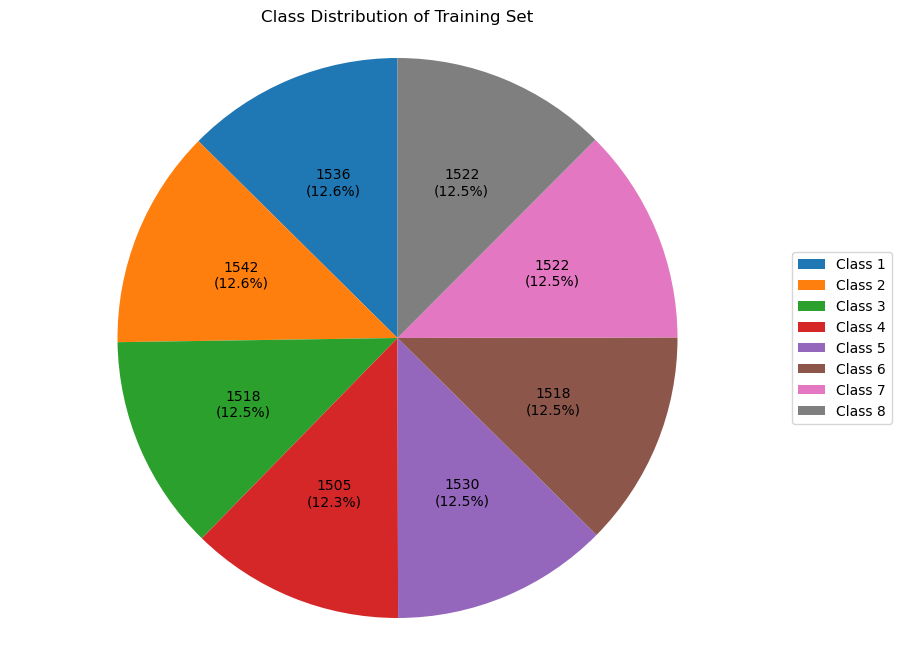


Validation Set Details
  Shape       : (800, 354)
  Label shape : (800,)


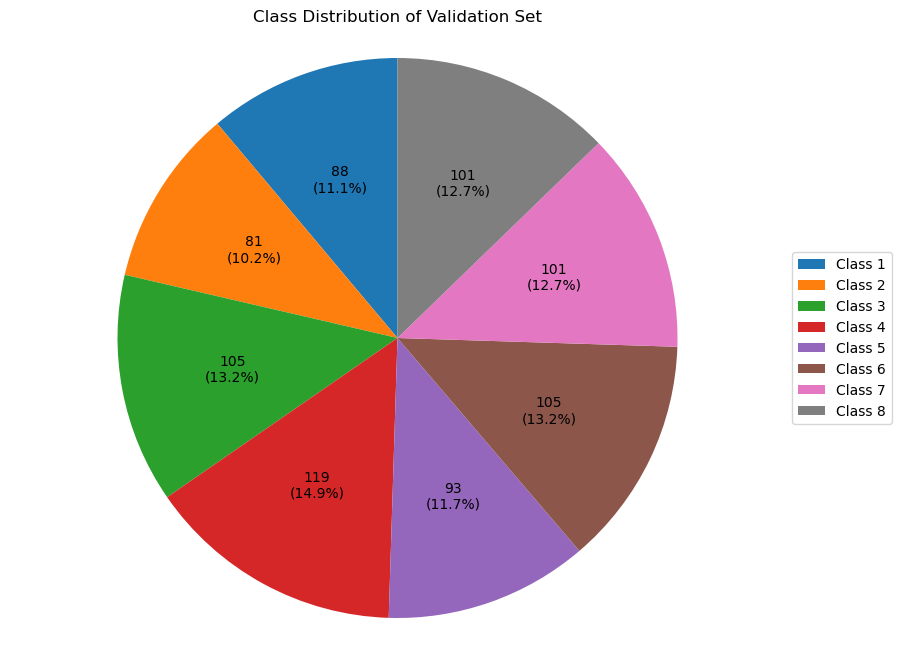

In [156]:
split = Partition(X_balanced, y_balanced)
split.printdetails()

## Batch Size

The batch size of the network determines the batches of vectorized code that will be processed at a time for each epoch.

> mini-batch size = 8 by default

In [157]:
def minibatch(trainingset, traininglabels, batch_size=8):
    N = len(trainingset)
    indices = np.arange(N)
    for start in range(0, N, batch_size):
        i = indices[start : start + batch_size]
        yield trainingset[i], traininglabels[i]

In [158]:
batch_size = 8 #edit this to get the batch size you need
minibatch(split.trainingset, split.traininglabels, batch_size)

<generator object minibatch at 0x3038d3640>

# Setting up the Equations

The backpropagation algorithm...

## Full Equation Reference: Backpropagation Algorithm

> **Notation**
> | Symbol | Meaning |
> |--------|---------|
> | $L$ | Total number of layers (output layer index) |
> | $l$ | Current layer index, $l \in \{1, \dots, L\}$ |
> | $i$ | Index of neuron in layer $l-1$; $i = 0$ is the bias input |
> | $j$ | Index of neuron in layer $l$ |
> | $k$ | Index of neuron in output layer $L$ |
> | $w^{(l)}_{j0}$ | Bias weight of neuron $j$ in layer $l$ (fixed input $\varphi_0 = +1$) |
> | $w^{(l)}_{ji}$ | Weight from neuron $i$ in layer $l-1$ to neuron $j$ in layer $l$ |
> | $v^{(l)}_j$ | Internal activity (pre-activation) of neuron $j$ in layer $l$ |
> | $\varphi_j$ | Activation function of neuron $j$; output $\varphi_j\!\left(v^{(l)}_j\right)$ |
> | $d_k$ | Desired (target) output for output neuron $k$ |
> | $e_k(n)$ | Error at output neuron $k$ at epoch $n$ |
> | $\mathcal{E}(n)$ | Mean square error over all output neurons at epoch $n$ |
> | $\eta$ | Learning rate |
> | $\alpha$ | Momentum coefficient |
> | $\gamma$ | Leaky ReLU negative-side slope, $\gamma \in (0,1)$ |
> | $n$ | Discrete time step (epoch) |
 
---

## 1. Forward Propagation to get internal activity $v(n)$ and outputs $y_{out}$

### 1.1 Internal Activity
 
The sum begins at $i = 0$ to include the bias weight $w^{(l)}_{j0}$ directly. The bias neuron has a fixed output of $+1$, so $w^{(l)}_{j0} \cdot 1 = w^{(l)}_{j0}$:
 
$$v^{(l)}_j(n) = \sum_{i=0}^{p} w^{(l)}_{ji}(n)\, \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
where $p$ is the number of neurons in layer $l-1$ (excluding the bias), and the bias input is $\varphi_0 = +1$ (constant).
 
### 1.2 Neuron Output
 
$$\varphi_j\!\left(v^{(l)}_j(n)\right)$$
 
where $\varphi_j$ is the chosen activation function (see Section 2).

## 2. Choosing the Activation Functions
 
Derivatives are expressed in terms of the neuron output $o(n) = \varphi(v(n))$ directly, using constants $a$ and $b$ where applicable.
 
### 2.1 Logistic (Sigmoid)
 
$$\varphi(v) = \frac{1}{1 + e^{-av}}, \quad a > 0$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = a \cdot o(n)\,\bigl(1 - o(n)\bigr)$$

> Given: $a = 2.0$
 
---
 
### 2.2 Hyperbolic Tangent (Tanh)
 
$$\varphi(v) = a \tanh(bv) = a \cdot \frac{e^{bv} - e^{-bv}}{e^{bv} + e^{-bv}}$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = \frac{b}{a}\left(a - o(n)\right)\!\left(a + o(n)\right)$$
 
> Given: $a = 1.716,\; b = 2/3$ (Le Cun's Parameters).
 
---
 
### 2.3 Leaky ReLU
 
$$\varphi(v) = \begin{cases} v & \text{if } v > 0 \\ \gamma\, v & \text{if } v \leq 0 \end{cases}, \quad \gamma \in (0,1)$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = \begin{cases} 1 & \text{if } o(n) > 0 \\ \gamma & \text{if } o(n) \leq 0 \end{cases}$$
 
---

In [159]:
# ACTIVATION FUNCTIONS
def logistic(v, a=1.0):
    phi = 1.0 / (1.0 + np.exp(-a * v))
    return phi

def tanh(v, a=1.0, b=1.0):
    phi = a * np.tanh(b * v)
    return phi
 
def leakyrelu(v, gamma=0.01):
    phi = np.where(v > 0, v, gamma * v)
    return phi
 
def errorSignal(dk, phiVk):
    return dk - phiVk
 
def meanSquareError(ek):
    return 0.5 * np.dot(ek, ek)

# DERIVATIVES
RELU_CLIP = 5.0 #for relu to converge

def dlogistic(o, a=1.0):
    dphi = a * o * (1.0 - o)
    return dphi
 
def dtanh(o, a=1.0, b=1.0):
    dphi = (b / a) * (a - o) * (a + o)
    return dphi
 
def dleakyrelu(o, gamma=0.01):
    dphi = np.where(o > 0, 1.0, gamma)
    return dphi
 
# DERIVATIVE CALL
def callDerivative(method, o, config):
    if method == 0:
        return dlogistic(o, config['a_l']), None
    elif method == 1:
        return dtanh(o, config['a_tanh'], config['b_tanh']), None
    else:
        return dleakyrelu(o, config['a_relu']), RELU_CLIP
 
# ACTIVATION CALL
def callActivation(method, v, config):
    if method == 0:
        return logistic(v, config['a_l'])
    elif method == 1:
        return tanh(v, config['a_tanh'], config['b_tanh'])
    else:
        return leakyrelu(v, config['a_relu'])

## 3. Error & Mean Square Error
 
### 3.1 Error Signal at Output Neuron $k$
 
$$e_k(n) = d_k(n) - \varphi_k\!\left(v^{(L)}_k(n)\right)$$
 
### 3.2 Mean Square Error
 
$$\mathcal{E}(n) = \frac{1}{2} \sum_{k \in \mathcal{C}} e_k^2(n)$$
 
where $\mathcal{C}$ is the set of output neurons.
 
---

## 4. Backpropagation Delta Equations
 
### 4.1 Output Layer Delta
 
$$\delta^{(L)}_k(n) = e_k(n) \cdot \varphi'\!\left(v^{(L)}_k(n)\right)$$
 
### 4.2 Hidden Layer Delta
 
For layer $l \in \{L-1,\, L-2,\, \dots,\, 1\}$:
 
$$\delta^{(l)}_j(n) = \varphi'\!\left(v^{(l)}_j(n)\right) \cdot \sum_{k}\, \delta^{(l+1)}_k(n)\, w^{(l+1)}_{kj}(n)$$
 
The hidden-layer delta propagates the error signal backward by weighting each upstream delta $\delta^{(l+1)}_k$ by the corresponding weight $w^{(l+1)}_{kj}$ and scaling by the local derivative $\varphi'(v^{(l)}_j)$.
 
---

## 5. Weight Update: Negative Gradient with Momentum
 
All weights $w^{(l)}_{ji}$ include the bias weights at $i = 0$ (with fixed input $\varphi_0 = +1$). No separate bias update is needed.
 
The weight correction follows the **negative gradient** of $\mathcal{E}(n)$ with respect to $w^{(l)}_{ji}$:
 
$$-\frac{\partial \mathcal{E}(n)}{\partial w^{(l)}_{ji}(n)} = \delta^{(l)}_j(n) \cdot \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
### 5.1 Weight Increment (Generalized Delta Rule + Momentum)
 
$$\Delta w^{(l)}_{ji}(n) = \underbrace{\alpha\, \Delta w^{(l)}_{ji}(n-1)}_{\text{momentum}} \;-\; \underbrace{\eta\, \frac{\partial \mathcal{E}(n)}{\partial w^{(l)}_{ji}(n)}}_{\text{negative gradient}}$$
 
Substituting the gradient expression:
 
$$\Delta w^{(l)}_{ji}(n) = \alpha\, \Delta w^{(l)}_{ji}(n-1) \;+\; \eta\, \delta^{(l)}_j(n)\, \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
### 5.2 Weight Update Rule
 
$$w^{(l)}_{ji}(n+1) = w^{(l)}_{ji}(n) + \Delta w^{(l)}_{ji}(n)$$
 
> **Bias weights** ($i = 0$) are updated identically using $\varphi_0 = +1$, so:
> $$\Delta w^{(l)}_{j0}(n) = \alpha\, \Delta w^{(l)}_{j0}(n-1) \;+\; \eta\, \delta^{(l)}_j(n)$$
 
> **Momentum note:** When $\alpha = 0$, this reduces to the standard (vanilla) delta rule. When $\alpha > 0$, the update accumulates a fraction of the previous step, smoothing oscillations and accelerating convergence along consistent gradient directions.
 
---

In [169]:
class OutputLayer:
    def __init__(self, method, w_old, config, dw_prev=None):
        self.config = config
        self.method = method
        self.v = []
        self.o = []
        self.d = []
        self.w_old = w_old
        self.size = config['size']
        self.delta = []
        self.error = []
        self.mse = 0.0
        self.w_new = []
 
        self.dw_prev = dw_prev if dw_prev is not None else np.zeros_like(w_old)
        self.phiIn = None
        self.gradient = np.zeros_like(w_old)
 
    def forward(self, phiIn):
        self.phiIn = phiIn
        self.v = self.w_old @ phiIn
        self.o = callActivation(self.method, self.v, self.config)
 
    def computeError(self, d):
        self.d = np.asarray(d, dtype=float)
        self.error = errorSignal(self.d, self.o)
        self.mse = meanSquareError(self.error)
 
    def computeDelta(self):
        dphi, _ = callDerivative(self.method, self.o, self.config)
        self.delta = self.error * dphi
 
    def accumulateGradient(self):
        self.gradient += np.outer(self.delta, self.phiIn)
 
    def resetGradient(self):
        self.gradient = np.zeros_like(self.w_old)
 
    def updateWeights(self, batch_size=1):
        dw = self.config['alpha'] * self.dw_prev + self.config['eta'] * (self.gradient / batch_size)
        self.w_new = self.w_old + dw
        self.dw_prev = dw
        self.gradient = np.zeros_like(self.w_old)
 
 
class HiddenLayer:
    def __init__(self, method, w_old, config, size=8, dw_prev=None):
        self.config = config
        self.method = method
        self.v = []
        self.y = []
        self.w_old = w_old
        self.size = size
        self.delta = 0.0
        self.w_new = []

        self.dw_prev = dw_prev if dw_prev is not None else np.zeros_like(w_old)
        self.phiIn = None
        self.gradient = np.zeros_like(w_old)
 
    def forward(self, phiIn):
        self.phiIn = phiIn
        self.v = self.w_old @ phiIn
        self.y = callActivation(self.method, self.v, self.config)
        return np.concatenate(([1.0], self.y))
 
    def computeDelta(self, nextLayer):
        dphi, _ = callDerivative(self.method, self.y, self.config)
        w_nobias = nextLayer.w_old[:, 1:]
        propagated = w_nobias.T @ nextLayer.delta
        self.delta = dphi * propagated
 
    def accumulateGradient(self):
        self.gradient += np.outer(self.delta, self.phiIn)
 
    def resetGradient(self):
        self.gradient = np.zeros_like(self.w_old)
 
    def updateWeights(self, batch_size=1):
        dw = self.config['alpha'] * self.dw_prev + self.config['eta'] * (self.gradient / batch_size)
        _, clip = callDerivative(self.method, self.y, self.config)
        if clip is not None:
            norm = np.linalg.norm(dw)
            if norm > clip:
                dw = dw * (clip / norm)
        self.w_new = self.w_old + dw
        self.dw_prev = dw
        self.gradient = np.zeros_like(self.w_old)
        return self.w_new
 
 
class Epoch:
    def __init__(self, split, config):
        self.config = config

        inputsize  = split.trainingset.shape[1] + 1
        hiddensize = config['size']
        outputsize = len(split.classes)
        #randomizing start weights
        Wi = np.random.randn(hiddensize, inputsize) * 0.01
        Wj = np.random.randn(hiddensize, hiddensize + 1)  * 0.01
        Wk = np.random.randn(outputsize, hiddensize + 1)  * 0.01

        self.hiddenlayer_i = HiddenLayer(config['methods'][0], Wi, config, size=hiddensize)
        self.hiddenlayer_j = HiddenLayer(config['methods'][1], Wj, config, size=hiddensize)
        self.outputlayer_k = OutputLayer(config['methods'][2], Wk, config)

        self.test_set = list(zip(split.validationset, split.validationlabels))
        self.error = 0.0
        self.iteration = 1
        self.tp = self.tn = self.fp = self.fn = 0.0
        self.p = self.r = self.a = self.f1 = self.matthews = 0.0

        self.trainingset = split.trainingset
        self.traininglabels = split.traininglabels
 
    def run(self, x, d):
        x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
 
        # Forward Prop
        phi_i = self.hiddenlayer_i.forward(x_biased)
        phi_j = self.hiddenlayer_j.forward(phi_i)
        self.outputlayer_k.forward(phi_j)
 
        # Error calcs
        self.outputlayer_k.computeError(d)
        self.error = self.outputlayer_k.mse
 
        # Backprop
        self.outputlayer_k.computeDelta()
        self.hiddenlayer_j.computeDelta(self.outputlayer_k)
        self.hiddenlayer_i.computeDelta(self.hiddenlayer_j)
 
        # Accumulate (batch_size=1, so gradient = outer(delta, phiIn))
        self.outputlayer_k.accumulateGradient()
        self.hiddenlayer_j.accumulateGradient()
        self.hiddenlayer_i.accumulateGradient()
 
        # Weight updates
        self.outputlayer_k.updateWeights()
        self.hiddenlayer_j.updateWeights()
        self.hiddenlayer_i.updateWeights()
 
        # Advance w_old → w_new
        self.outputlayer_k.w_old = self.outputlayer_k.w_new
        self.hiddenlayer_j.w_old = self.hiddenlayer_j.w_new
        self.hiddenlayer_i.w_old = self.hiddenlayer_i.w_new
 
        self.iteration += 1
 
    def run_batch(self, X_batch, D_batch):
        batch_size = len(X_batch)
        error = 0.0
 
        for SAMPLE in range(batch_size):
            x_biased = np.concatenate(([1.0], np.asarray(X_batch[SAMPLE], dtype=float)))
 
            # Forward Prop
            phi_i = self.hiddenlayer_i.forward(x_biased)
            phi_j = self.hiddenlayer_j.forward(phi_i)
            self.outputlayer_k.forward(phi_j)
 
            # Error calcs
            self.outputlayer_k.computeError(D_batch[SAMPLE])
            error += self.outputlayer_k.mse
 
            # Backprop
            self.outputlayer_k.computeDelta()
            self.hiddenlayer_j.computeDelta(self.outputlayer_k)
            self.hiddenlayer_i.computeDelta(self.hiddenlayer_j)
 
            # Accumulate
            self.outputlayer_k.accumulateGradient()
            self.hiddenlayer_j.accumulateGradient()
            self.hiddenlayer_i.accumulateGradient()
 
        # Weight updates uses batch_size from config
        self.outputlayer_k.updateWeights(batch_size)
        self.hiddenlayer_j.updateWeights(batch_size)
        self.hiddenlayer_i.updateWeights(batch_size)
 
        # Advance w_old to w_new
        self.outputlayer_k.w_old = self.outputlayer_k.w_new
        self.hiddenlayer_j.w_old = self.hiddenlayer_j.w_new
        self.hiddenlayer_i.w_old = self.hiddenlayer_i.w_new
 
        self.error = error / batch_size
        self.iteration += 1
        return self.error
 
    def Scores(self, threshold=0.5): 
        for x, d in self.test_set:
            x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
            phi_i = self.hiddenlayer_i.forward(x_biased)
            phi_j = self.hiddenlayer_j.forward(phi_i)
            self.outputlayer_k.forward(phi_j)
 
            predicted = np.argmax(self.outputlayer_k.o)
            actual = np.argmax(d)
 
            if   predicted == 1 and actual == 1:  self.tp += 1.0
            elif predicted == 0 and actual == 0:  self.tn += 1.0
            elif predicted == 1 and actual == 0:  self.fp += 1.0
            elif predicted == 0 and actual == 1:  self.fn += 1.0
 
        self.p = self.tp / (self.tp + self.fp) if (self.tp + self.fp) > 0 else 0.0
        self.r = self.tp / (self.tp + self.fn) if (self.tp + self.fn) > 0 else 0.0
        self.f1 = (2 * self.p * self.r / (self.p + self.r)) if (self.p + self.r) > 0 else 0.0
 
        total = self.tp + self.tn + self.fp + self.fn
        self.a = (self.tp + self.tn) / total if total > 0 else 0.0
 
        denom = np.sqrt((self.tp + self.fp) * (self.tp + self.fn) *
                                (self.tn + self.fp) * (self.tn + self.fn))
        self.matthews = (self.tp * self.tn - self.fp * self.fn) / denom if denom > 0 else 0.0
 
    def printScores(self):
        print("Confusion Matrix")
        print(f"TP: {self.tp:6.0f}      FP: {self.fp:6.0f}")
        print(f"FN: {self.fn:6.0f}      TN: {self.tn:6.0f}")
        print()
        print(f"Error (MSE): {self.error:.5f}")
        print(f"Accuracy: {self.a:.5f}")
        print(f"Precision: {self.p:.5f}")
        print(f"Recall: {self.r:.5f}")
        print(f"F1 Score: {self.f1:.5f}")
        print(f"Matthews CC: {self.matthews:.5f}")
 
    def exportErrors(self, filepath="export/errors.csv"):
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        writeHeader = not os.path.exists(filepath) or os.path.getsize(filepath) == 0
        with open(filepath, 'a', newline='') as f:
            writer = csv.writer(f)
            if writeHeader:
                writer.writerow(['iteration', 'error'])
            writer.writerow([self.iteration, self.error])
 
    def exportScores(self, filepath="export/scores.csv"):
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        writeHeader = not os.path.exists(filepath) or os.path.getsize(filepath) == 0
        with open(filepath, 'a', newline='') as f:
            writer = csv.writer(f)
            if writeHeader:
                writer.writerow(['iteration', 'accuracy', 'precision', 'recall', 'f1', 'matthews'])
            writer.writerow([self.iteration, self.a, self.p, self.r, self.f1, self.matthews])


# Training Phase

## Hyperparameters Setup

In [ ]:
#hyperparameters updated
class Network:
    A = {
        'methods'    : [1, 1, 0],  # [i, j, k] — 0 logistic, 1 tanh, 2 relu
        'a_l'        : 1.0,        # logistic slope
        'a_tanh'     : 1.716,      # tanh a
        'b_tanh'     : 0.66666,    # tanh b
        'a_relu'     : 0.01,       # leaky relu gamma
        'eta'        : 0.85,       # learning rate
        'alpha'      : 0.9,        # momentum constant
        'size'       : 8,          # hidden layer size
    }
    B = {
        'methods'    : [2, 2, 0],  # [i, j, k] — 0 logistic, 1 tanh, 2 relu
        'a_l'        : 1.0,        # logistic slope
        'a_tanh'     : 1.716,      # tanh a
        'b_tanh'     : 0.66666,    # tanh b
        'a_relu'     : 0.01,       # leaky relu gamma
        'eta'        : 0.85,       # learning rate
        'alpha'      : 0.9,        # momentum constant
        'size'       : 8,          # hidden layer size
    }
#the main engine:
epochA = Epoch(split, Network.A)  # layers built inside
epochB = Epoch(split, Network.B)

After setting up, the training phase begins.

In [ ]:
def train(epoch, epochs=100):
    b = batch_size
    for ep in range(epochs):
        for xbatch, dbatch in minibatch(epoch.trainingset, epoch.traininglabels, b):
            error = epoch.run_batch(xbatch, dbatch)
        if (ep + 1) % 5 == 0:
            print(f"Epoch {ep+1}  Error: {error:.5f}")
    epoch.printScores()
    epoch.print

In [184]:
train(epochB)

Epoch 5  Error: 92.50000
Epoch 10  Error: 92.50000
Epoch 15  Error: 92.50000
Epoch 20  Error: 92.50000
Epoch 25  Error: 92.50000
Epoch 30  Error: 92.50000
Epoch 35  Error: 92.50000
Epoch 40  Error: 92.50000
Epoch 45  Error: 92.50000
Epoch 50  Error: 92.50000
Epoch 55  Error: 92.50000
Epoch 60  Error: 92.50000
Epoch 65  Error: 92.50000
Epoch 70  Error: 92.50000
Epoch 75  Error: 92.50000
Epoch 80  Error: 92.50000
Epoch 85  Error: 92.50000
Epoch 90  Error: 92.50000
Epoch 95  Error: 92.50000
Epoch 100  Error: 92.50000


# Implementation



# Results

# Conclusion